In [15]:
#PENGUMPULAN DATA

import pandas as pd

data = pd.read_csv("dataset.csv")
print("sampel data: \n", data[:2])
print("\n")
print("jumlah baris dan kolom:", data.shape)
print("\n")
print("kolom dataset: \n", data.columns)
print("\n")


sampel data: 
   text_id annotators_id                                               text  \
0   1-Jan   ['7', '15']  Wajah Jurnalis Dibalut Perban Saat Melaporkan ...   
1  10-Jan   ['7', '15']  Elektabilitas Paslon 02 sebentar lagi terjun b...   

                                   initial_paragraph        topic  \
0  “️Jurnalis Hana Mahamed kembali tampil di tele...      UNKNOWN   
1                                                NaN  Disabilitas   

  is_noise_or_spam_text related_to_election_2024    toxicity   polarized  \
0            ['0', '0']               ['0', '0']  ['0', '0']  ['0', '0']   
1            ['0', '0']               ['1', '1']  ['0', '0']  ['1', '1']   

  profanity_obscenity threat_incitement_to_violence     insults  \
0          ['0', '0']                    ['0', '0']  ['0', '0']   
1          ['0', '0']                    ['0', '0']  ['0', '0']   

  identity_attack sexually_explicit  
0      ['0', '0']        ['0', '0']  
1      ['0', '0']        ['0', '0']

In [16]:
#DATA PREPROCESSING 1 FEATURE SELECTION
print("\n#DATA PREPROCESSING 1 FEATURE SELECTION\n")
print("Kolom dataset sebelum feature selection:")
print(data.columns)

kolom_dipake = [
    'text',
    'toxicity',
    'polarized',
    'annotators_id',
    'is_noise_or_spam_text'
]

# Memfilter dataset
data = data[kolom_dipake]

# Menampilkan 3 data teratas untuk memastikan kolom sudah lengkap
print("\nKolom dataset setelah feature selection: ")
print(data.columns)
print(data[:3])


#DATA PREPROCESSING 1 FEATURE SELECTION

Kolom dataset sebelum feature selection:
Index(['text_id', 'annotators_id', 'text', 'initial_paragraph', 'topic',
       'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity',
       'polarized', 'profanity_obscenity', 'threat_incitement_to_violence',
       'insults', 'identity_attack', 'sexually_explicit'],
      dtype='object')

Kolom dataset setelah feature selection: 
Index(['text', 'toxicity', 'polarized', 'annotators_id',
       'is_noise_or_spam_text'],
      dtype='object')
                                                text    toxicity   polarized  \
0  Wajah Jurnalis Dibalut Perban Saat Melaporkan ...  ['0', '0']  ['0', '0']   
1  Elektabilitas Paslon 02 sebentar lagi terjun b...  ['0', '0']  ['1', '1']   
2  Gini aja deh @KPU_ID usul aja nih. Gimana kalo...  ['1', '0']  ['0', '0']   

  annotators_id is_noise_or_spam_text  
0   ['7', '15']            ['0', '0']  
1   ['7', '15']            ['0', '0']  
2   ['7', '15']    

In [17]:
#DATA PREPROCESSING - CLEANING DATA
print("DATA PREPROCESSING 2 - CLEANING DATA 1 - HAPUS SPAM")
#hapus spam
total_spam = 0

import ast
# 1. Konversi string "[0, 1]" menjadi list asli [0, 1]
# Gunakan ast.literal_eval agar Python paham itu adalah list, bukan teks biasa
def safe_to_list(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return val
    return val

# Terapkan konversi pada kolom yang bermasalah
data['is_noise_or_spam_text'] = data['is_noise_or_spam_text'].apply(safe_to_list)

for i in range(len(data)):
    if '1' in str(data['is_noise_or_spam_text'][i]):
        total_spam += 1

print("\nJumlah data awal: ", len(data))
print("Jumlah data spam: ", total_spam)
print("jumlah data bukan spam: ", len(data) - total_spam)
print("\nMenghapus data spam...\n")
data = data[data['is_noise_or_spam_text'].apply(lambda x: '1' not in str(x))]
print("Jumlah data setelah penghapusan spam: ", len(data))


DATA PREPROCESSING 2 - CLEANING DATA 1 - HAPUS SPAM

Jumlah data awal:  28448
Jumlah data spam:  2884
jumlah data bukan spam:  25564

Menghapus data spam...

Jumlah data setelah penghapusan spam:  25564


In [18]:
#DATA PREPROCESSING 2 - CLEANING DATA 2 - rasio 50:50
print("\nDATA PREPROCESSING 2 - CLEANING DATA 2 - HAPUS rasio 50:50\n")

import ast
# 1. Fungsi untuk mengubah string "[ '0', '1']" menjadi list asli [0, 1]
def clean_label_format(val):
    if isinstance(val, str):
        try:
            # ast.literal_eval akan mengubah string "[ '0', '1']" menjadi list ['0', '1']
            res = ast.literal_eval(val)
            # Ubah tiap elemen menjadi integer: [0, 1]
            return [int(i) for i in res]
        except:
            return val
    return val

# Terapkan pembersihan format pada kolom toxicity dan polarized
data['toxicity'] = data['toxicity'].apply(clean_label_format)
data['polarized'] = data['polarized'].apply(clean_label_format)


# 2. Fungsi untuk mengecek rasio 50% (Perfect Disagreement)
def is_50_percent(labels):
    if isinstance(labels, list) and len(labels) > 0:
        # Menghitung rasio angka 1
        angka_1 = 0
        for i in labels:
            if i == 1:
                angka_1 += 1
        ratio = angka_1 / len(labels)
        return ratio == 0.5
    return False

# 3. Eksekusi Penghapusan sesuai instruksimu
jumlah_awal = len(data)
print(f"Jumlah baris awal sebelum penghapusan rasio 50:50: {jumlah_awal}")

# Hapus jika salah satu kolom (toxicity ATAU polarized) memiliki rasio 50:50

data = data[~(data['toxicity'].apply(is_50_percent) |
              data['polarized'].apply(is_50_percent))].copy()

print(f"jumlah baris yang memiliki rasio 50:50: {jumlah_awal - len(data)}")
print(f"jumlah baris yang tidak memiliki rasio 50:50: {len(data)}")
print(f"\nPembersihan 50:50 dilakukan!\n")
print(f"jumlah baris data setelah dilakukan penghapusan rasio 50:50: {len(data)} baris")


DATA PREPROCESSING 2 - CLEANING DATA 2 - HAPUS rasio 50:50

Jumlah baris awal sebelum penghapusan rasio 50:50: 25564
jumlah baris yang memiliki rasio 50:50: 3285
jumlah baris yang tidak memiliki rasio 50:50: 22279

Pembersihan 50:50 dilakukan!

jumlah baris data setelah dilakukan penghapusan rasio 50:50: 22279 baris


In [19]:
# PREPROCESSING DATA - CLEANING DATA 3 - MISSING VALUES
print("\nDATA PREPROCESSING 3 - CLEANING DATA 3 - HAPUS MISSING VALUES\n")

# 1. Cek missing values
print("Jumlah missing values sebelum penghapusan:")
print(data.isnull().sum())

# 2. Hapus baris dengan missing values
data = data.dropna()

print("Jumlah missing values setelah penghapusan:")
print(data.isnull().sum())
print(f"Jumlah baris data setelah dilakukan penghapusan missing values: {len(data)} baris")


DATA PREPROCESSING 3 - CLEANING DATA 3 - HAPUS MISSING VALUES

Jumlah missing values sebelum penghapusan:
text                     1
toxicity                 0
polarized                0
annotators_id            0
is_noise_or_spam_text    0
dtype: int64
Jumlah missing values setelah penghapusan:
text                     0
toxicity                 0
polarized                0
annotators_id            0
is_noise_or_spam_text    0
dtype: int64
Jumlah baris data setelah dilakukan penghapusan missing values: 22278 baris


In [20]:
#NORMALISASI DATA - PENYERAGAMAN TEKS
print("\nNORMALISASI DATA - PENYERAGAMAN TEKS\n")

import re
# 1. Pastikan semua data di kolom text adalah string dan tangani nilai kosong (NaN)
data['text'] = data['text'].astype(str).fillna('')

# 2. Jalankan kembali fungsi normalisasi yang sudah diperbaiki
def data_normalization(text):
    # Tambahkan pengecekan tipe data untuk keamanan ekstra
    if not isinstance(text, str):
        text = str(text)

    # Ganti URL
    text = re.sub(r'http\S+|www\S+|https\S+', 'url', text, flags=re.MULTILINE)

    # Ganti Mention (@) menjadi username
    text = re.sub(r'@\w+', 'username', text)

    # Ganti Hashtag (#)
    text = re.sub(r'#\w+', 'hashtag', text)

    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan ke dataset
print("sampel data sebelum dilakukan normalisasi:")
for i, teks in enumerate(data['text'][:3]):
    print(f"Baris {i+1}: {teks}")
    print("-" * 50) # Garis pembatas agar mudah dibaca

data['text'] = data['text'].apply(data_normalization)
print("\nNormalisasi dilakukan!\n")

print("sampel data setelah dilakukan normalisasi:")
for i, teks in enumerate(data['text'][:3]):
    print(f"Baris {i+1}: {teks}")
    print("-" * 50) # Garis pembatas agar mudah dibaca



NORMALISASI DATA - PENYERAGAMAN TEKS

sampel data sebelum dilakukan normalisasi:
Baris 1: Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
--------------------------------------------------
Baris 2: Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
--------------------------------------------------
Baris 3: Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir
--------------------------------------------------

Normalisasi dilakukan!

sampel data setelah dilakukan normalisasi:
Baris 1: Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
--------------------------------------------------
Baris 2: Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
--------------------------------------------------
Baris 3: Kristen, Hindu, Islam dapa

In [21]:
#DATA PREPROCESSING - normalisasi data 4 - EMOJI

import emoji

# 1. Buat filter: cari baris yang jumlah emojinya lebih dari 0
kondisi_ada_emoji = data['text'].apply(lambda x: emoji.emoji_count(str(x)) > 0)

# 2. Ambil data yang hanya berisi emoji, lalu pilih 3 secara acak
data_dengan_emoji = data[kondisi_ada_emoji].sample(3).copy()

# 3. Tampilkan hasilnya (Sebelum vs Sesudah)
for index, row in data_dengan_emoji.iterrows():
    teks_asli = row['text']

    # Lakukan demojize dan bersihkan karakternya
    teks_sesudah = emoji.demojize(str(teks_asli)).replace(":", " ").replace("_", " ")

    # Rapikan spasi ganda
    teks_sesudah = " ".join(teks_sesudah.split())

    print(f"--- sampel baris text_id: {data.loc[index, 'text_id'] if 'text_id' in data.columns else index} ---")
    print(f"SEBELUM : {teks_asli}")
    print(f"SESUDAH : {teks_sesudah}")
    print("-" * 50)

data['text'] = data['text'].apply(lambda x: emoji.demojize(str(x)).replace(":", " ").replace("_", " "))

--- sampel baris text_id: 6670 ---
SEBELUM : Assalamualaikum 🙏 mengingat kembali,sekarang di Indonesia gencar mengampanyekan boikot produk Israel, dulu salah satu gubernur jawa tengah yaitu bpk Ganjar Pranowo menolak Israel ikut peserta piala dunia sepak bola yg diadakan di Indonesia,dan akhirnya Indonesia gagal menjadi tuan rumah karena mengusir Israel menginjak bumi Pertiwi ini,orang sibuk menyalahkan beliau,karena indonesia sudah mempunyai JIS ( jakarta internasional stadium) maha karya Anis baswedan sudah pantas menjadi tuan rumah piala dunia,pada kemana Anis,Prabowo,apa yg mereka lakukan,mana yg nasionalisme yg sangat tinggi,mana yg keislamannya sangat kuat,Ganjar kah,Anis kah,atau Prabowo. Kita pasti sudah tahu pasti bpk Ganjar Pranowo calon presiden kita, insyaallah Ganjar Pranowo presiden RI 2024 Aamiin 🤲.tak terbantahkan 🙏🙏
SESUDAH : Assalamualaikum folded hands mengingat kembali,sekarang di Indonesia gencar mengampanyekan boikot produk Israel, dulu salah satu gubernur jawa te

In [22]:
# 1. Simpan salinan 3 data pertama SEBELUM diubah
teks_sebelum = data['text'][:3].copy()

# 2. Lakukan normalisasi case folding pada seluruh data
data['text'] = data['text'].str.lower()

print("\nNormalisasi case folding dilakukan!\n")
print("Sampel data sebelum dan setelah dilakukan normalisasi case folding:")

# 3. Tampilkan perbandingan menggunakan salinan yang tadi disimpan
for i in range(3):
    print(f"Sebelum : {teks_sebelum.iloc[i]}")
    print(f"Sesudah : {data['text'].iloc[i]}")
    print("-" * 50)


Normalisasi case folding dilakukan!

Sampel data sebelum dan setelah dilakukan normalisasi case folding:
Sebelum : Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
Sesudah : wajah jurnalis dibalut perban saat melaporkan kondisi di gaza 2023
--------------------------------------------------
Sebelum : Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
Sesudah : elektabilitas paslon 02 sebentar lagi terjun bebas gara2 gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, ijazah dan tidak hadir
--------------------------------------------------
Sebelum : Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir
Sesudah : kristen, hindu, islam dapat perlakuan istimewa dari pak anies ncep ketar-ketir
--------------------------------------------------


In [23]:
# FEATURE ENGINEERING - soft and hard labelling

#feature engineering

import pandas as pd
import numpy as np

def run_feature_engineering(df):
    # --- 1. Fungsi untuk Soft Label (Label Distribution Learning) ---
    def to_soft_label(labels):
        if isinstance(labels, list) and len(labels) > 0:
            total_anotator = len(labels)
            # Menghitung jumlah anotator yang memberikan nilai 1
            count_1 = sum(1 for i in labels if str(i) == '1')

            # Rasio untuk kelas positif (1) dan negatif (0)
            ratio_1 = round(count_1 / total_anotator, 2)
            ratio_0 = round(1.0 - ratio_1, 2)

            # Format output berupa distribusi probabilitas [prob_1, prob_0]
            # Contoh kasus: [1, 0, 0, 1] -> count_1 = 2, total = 4 -> [0.5, 0.5] (50:50)
            return [ratio_1, ratio_0]
        return [0.0, 1.0] # Default jika data kosong

    # --- 2. Fungsi untuk Hard Label (Majority Voting / Faktor Agregat) ---
    def to_hard_label(labels):
        if isinstance(labels, list) and len(labels) > 0:
            total_anotator = len(labels)
            count_1 = sum(1 for i in labels if str(i) == '1')

            # Majority Voting: Jika rasio nilai 1 lebih dari 50%, maka label final adalah 1
            # Jika seimbang atau lebih banyak 0, maka label final adalah 0
            return 1 if (count_1 / total_anotator) > 0.5 else 0
        return 0

    # --- 3. Eksekusi Pembuatan Kolom Baru ---
    # Membuat kolom Soft Label
    df['soft_toxic'] = df['toxicity'].apply(to_soft_label)
    df['soft_polarized'] = df['polarized'].apply(to_soft_label)

    # Membuat kolom Hard Label
    df['hard_toxic'] = df['toxicity'].apply(to_hard_label)
    df['hard_polarized'] = df['polarized'].apply(to_hard_label)

    return df

# Terapkan fungsi ke dataset kamu
data = run_feature_engineering(data)

# --- 4. Cek Hasil Perubahan ---
print("--- Sampel Data Hasil Feature Engineering ---")
print(data[['toxicity', 'soft_toxic', 'hard_toxic']].head())
print(data[['polarized', 'soft_polarized', 'hard_polarized']].head())
print("kolom data setelah feature engineering: \n", data.columns)

--- Sampel Data Hasil Feature Engineering ---
   toxicity  soft_toxic  hard_toxic
0    [0, 0]  [0.0, 1.0]           0
1    [0, 0]  [0.0, 1.0]           0
4    [0, 0]  [0.0, 1.0]           0
8    [0, 0]  [0.0, 1.0]           0
12   [0, 0]  [0.0, 1.0]           0
   polarized soft_polarized  hard_polarized
0     [0, 0]     [0.0, 1.0]               0
1     [1, 1]     [1.0, 0.0]               1
4     [1, 1]     [1.0, 0.0]               1
8     [0, 0]     [0.0, 1.0]               0
12    [0, 0]     [0.0, 1.0]               0
kolom data setelah feature engineering: 
 Index(['text', 'toxicity', 'polarized', 'annotators_id',
       'is_noise_or_spam_text', 'soft_toxic', 'soft_polarized', 'hard_toxic',
       'hard_polarized'],
      dtype='object')


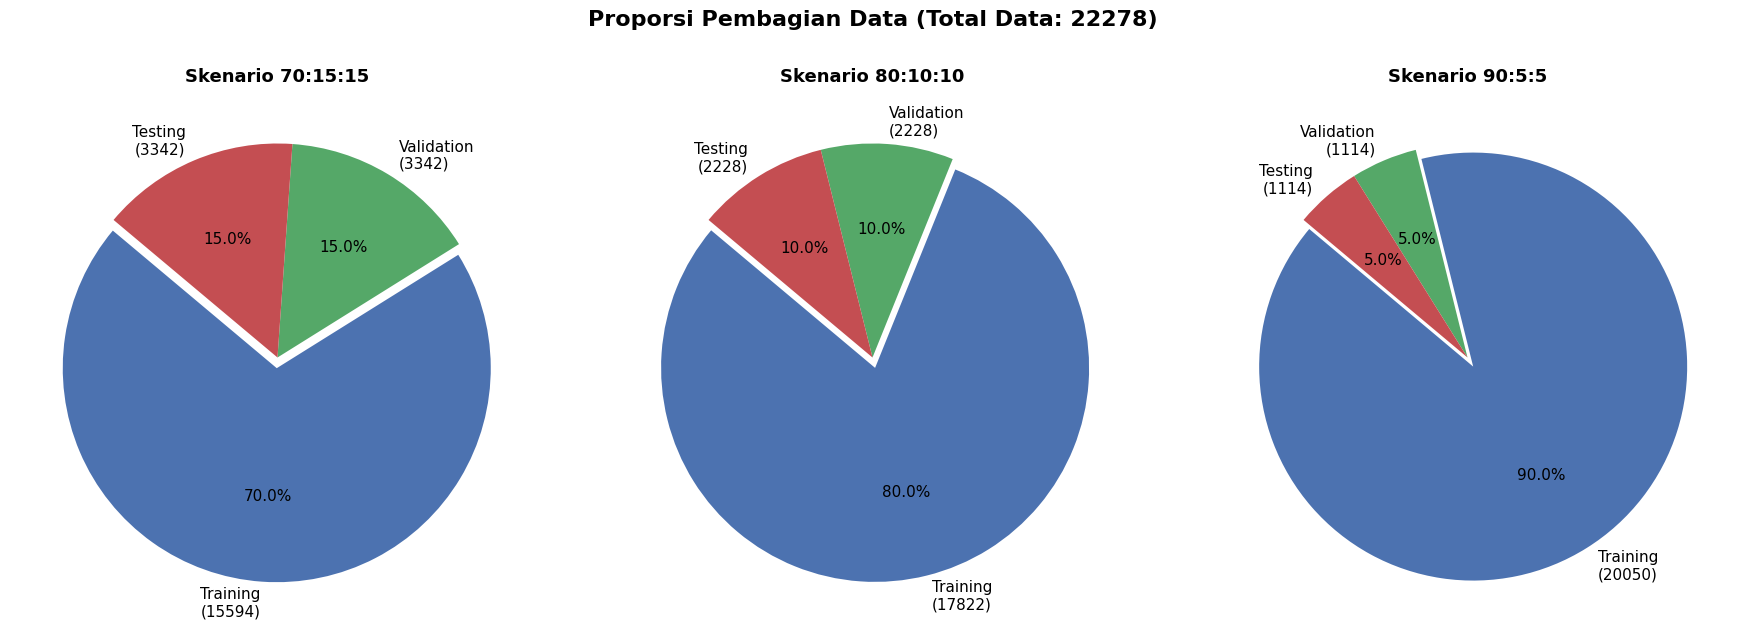

In [24]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. PROSES DATA SPLITTING
# ==========================================
# Skenario 1: 70:15:15
train_data1, temp_data1 = train_test_split(data, test_size=0.3, random_state=42)
val_data1, test_data1 = train_test_split(temp_data1, test_size=0.5, random_state=42)

# Skenario 2: 80:10:10
train_data2, temp_data2 = train_test_split(data, test_size=0.2, random_state=42)
val_data2, test_data2 = train_test_split(temp_data2, test_size=0.5, random_state=42)

# Skenario 3: 90:5:5
train_data3, temp_data3 = train_test_split(data, test_size=0.1, random_state=42)
val_data3, test_data3 = train_test_split(temp_data3, test_size=0.5, random_state=42)

# ==========================================
# 2. VISUALISASI DENGAN PIE CHART
# ==========================================
def plot_split_pie(train_len, val_len, test_len, judul, ax):
    # Data untuk pie chart
    sizes = [train_len, val_len, test_len]
    labels = [f'Training\n({train_len})', f'Validation\n({val_len})', f'Testing\n({test_len})']

    # Pengaturan warna agar menarik
    colors = ['#4C72B0', '#55A868', '#C44E52']

    # Memberi efek potongan sedikit keluar pada porsi Training
    explode = (0.05, 0, 0)

    # Membuat pie chart di axis yang ditentukan
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
    ax.set_title(judul, fontweight='bold', fontsize=13)

# Membuat kanvas figure dengan 1 baris dan 3 kolom
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle(f'Proporsi Pembagian Data (Total Data: {len(data)})',
             fontsize=16, fontweight='bold', y=1.05)

# Plot masing-masing skenario ke dalam subplots
plot_split_pie(len(train_data1), len(val_data1), len(test_data1), 'Skenario 70:15:15', axes[0])
plot_split_pie(len(train_data2), len(val_data2), len(test_data2), 'Skenario 80:10:10', axes[1])
plot_split_pie(len(train_data3), len(val_data3), len(test_data3), 'Skenario 90:5:5', axes[2])

# Merapikan jarak antar grafik dan menampilkannya
plt.tight_layout()
plt.show()


Total Train Data 1 (70%): 15594 baris


C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


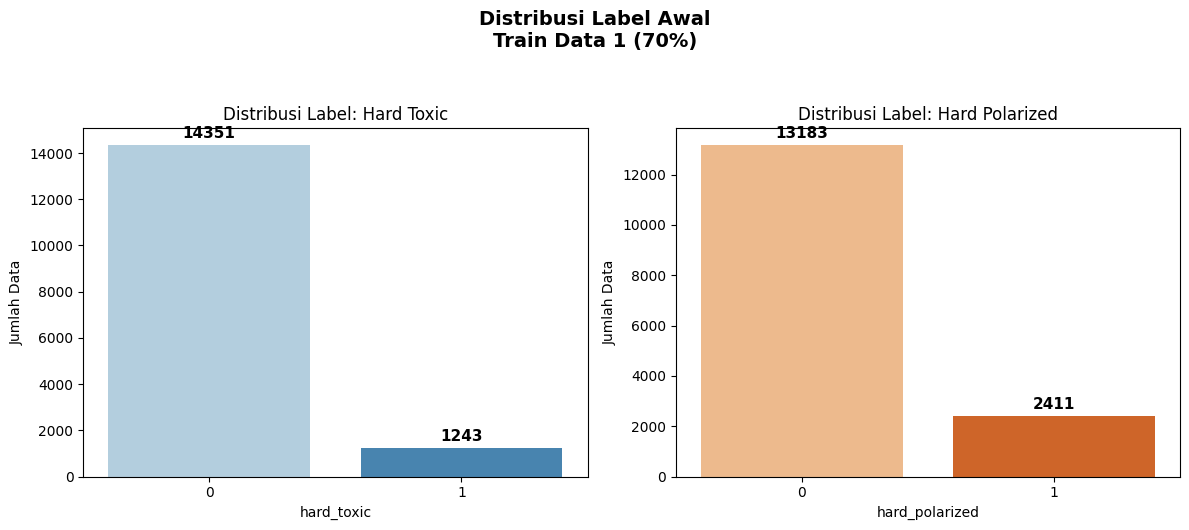


Total Train Data 2 (80%): 17822 baris


C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


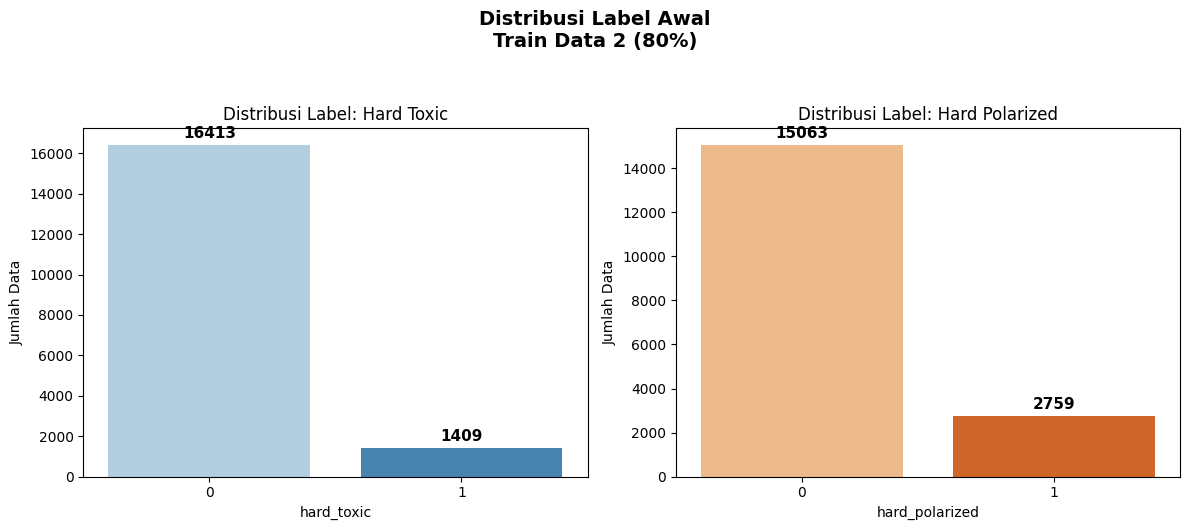


Total Train Data 3 (90%): 20050 baris


C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


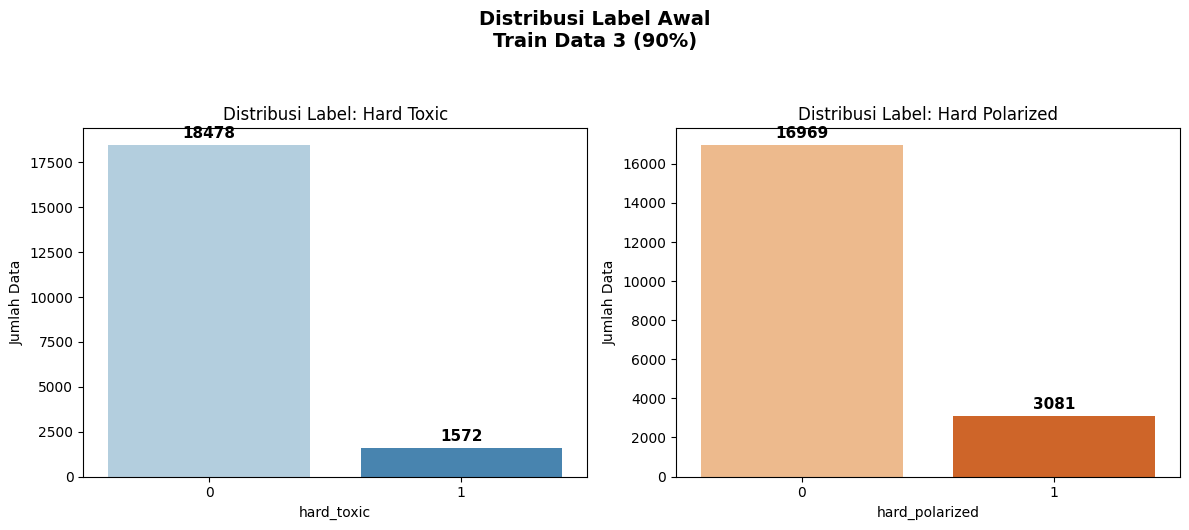

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribusi_awal(df, nama_data):
    # Cetak total data
    print(f"\n" + "="*40)
    print(f"Total {nama_data}: {len(df)} baris")
    print("="*40)

    # Membuat figure dengan 1 baris dan 2 kolom
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    fig.suptitle(f'Distribusi Label Awal\n{nama_data}', fontsize=14, fontweight='bold', y=1.05)

    # Plot 1: Distribusi Hard Toxic
    sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
    axes[0].set_title('Distribusi Label: Hard Toxic')
    axes[0].set_ylabel('Jumlah Data')

    # Plot 2: Distribusi Hard Polarized
    sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')
    axes[1].set_title('Distribusi Label: Hard Polarized')
    axes[1].set_ylabel('Jumlah Data')

    # Menambahkan angka jumlah data di atas masing-masing batang (bar)
    for ax in axes:
        for p in ax.patches:
            height = p.get_height()
            if height > 0: # Pastikan tinggi bar > 0 agar tidak error
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 3), textcoords='offset points',
                            fontsize=11, fontweight='bold')

    # Merapikan dan menampilkan plot
    plt.tight_layout()
    plt.show()

# ==========================================
# EKSEKUSI UNTUK SEMUA DATA TRAIN
# ==========================================

# 1. Plot Distribusi train_data1 (70%)
plot_distribusi_awal(train_data1, "Train Data 1 (70%)")

# 2. Plot Distribusi train_data2 (80%)
plot_distribusi_awal(train_data2, "Train Data 2 (80%)")

# 3. Plot Distribusi train_data3 (90%)
plot_distribusi_awal(train_data3, "Train Data 3 (90%)")


       PROSES RUS: Data 1 (70%)



C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized'

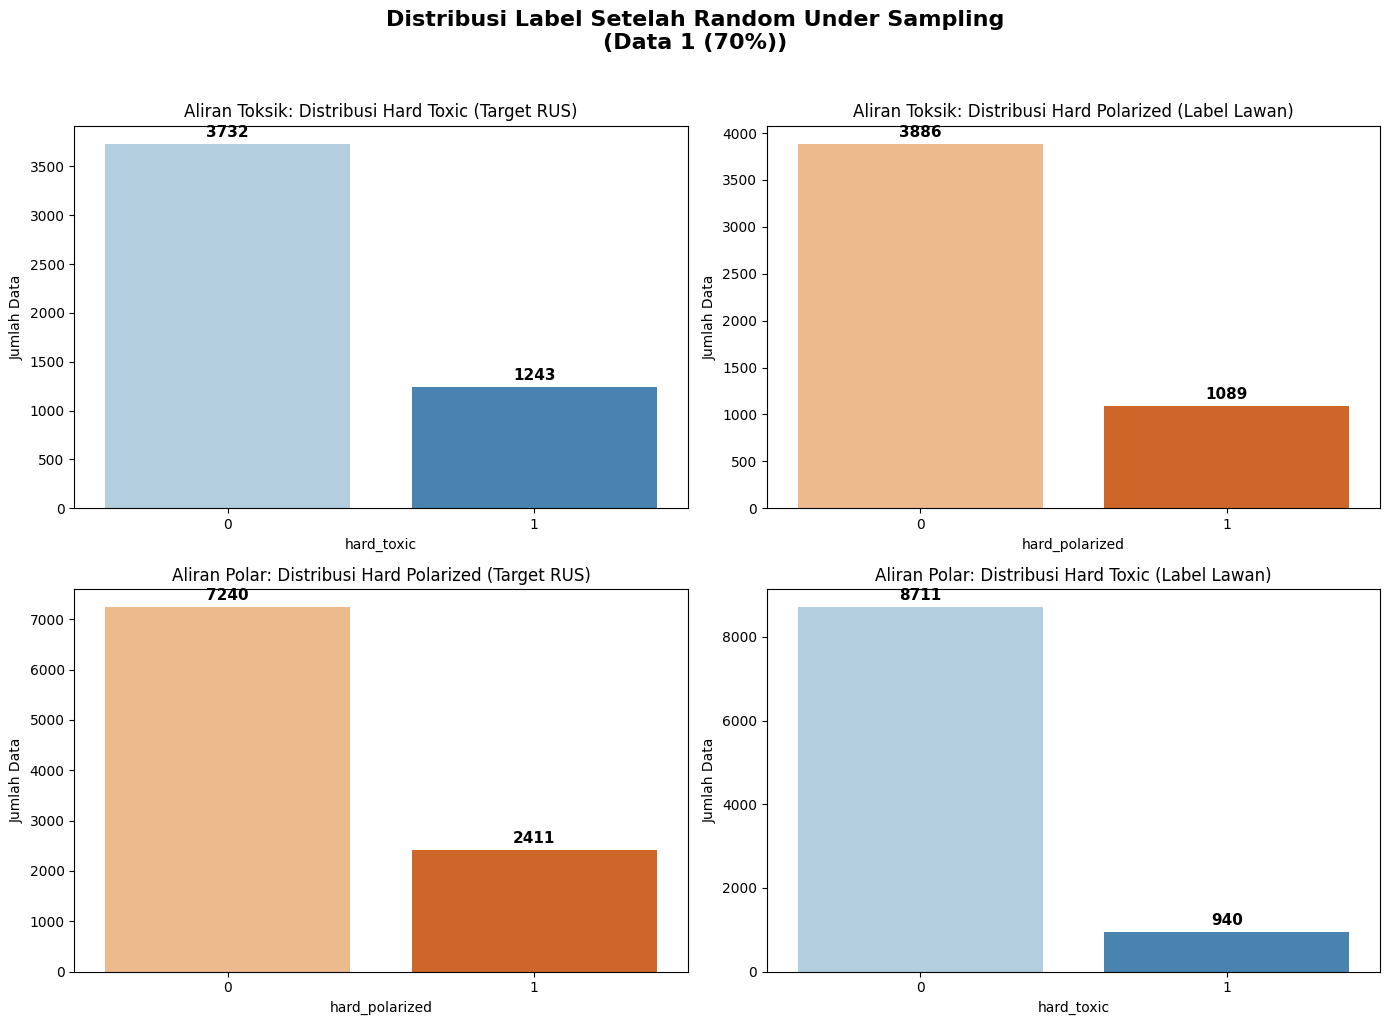


       PROSES RUS: Data 2 (80%)



C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized'

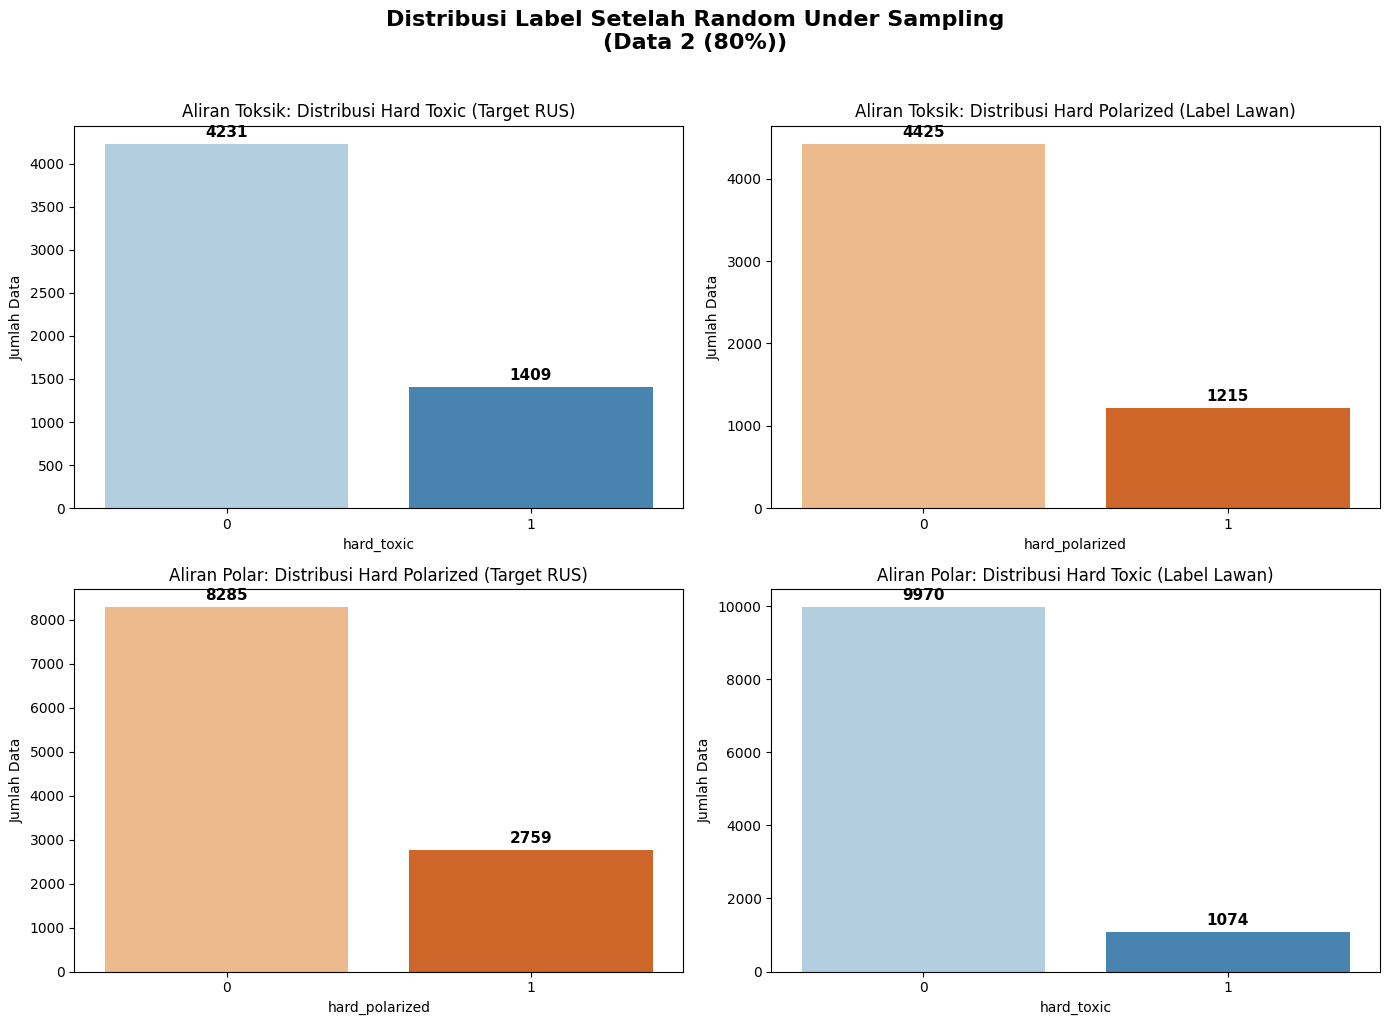


       PROSES RUS: Data 3 (90%)



C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
C:\Users\Sultan Daris\AppData\Local\Temp\ipykernel_4312\1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized'

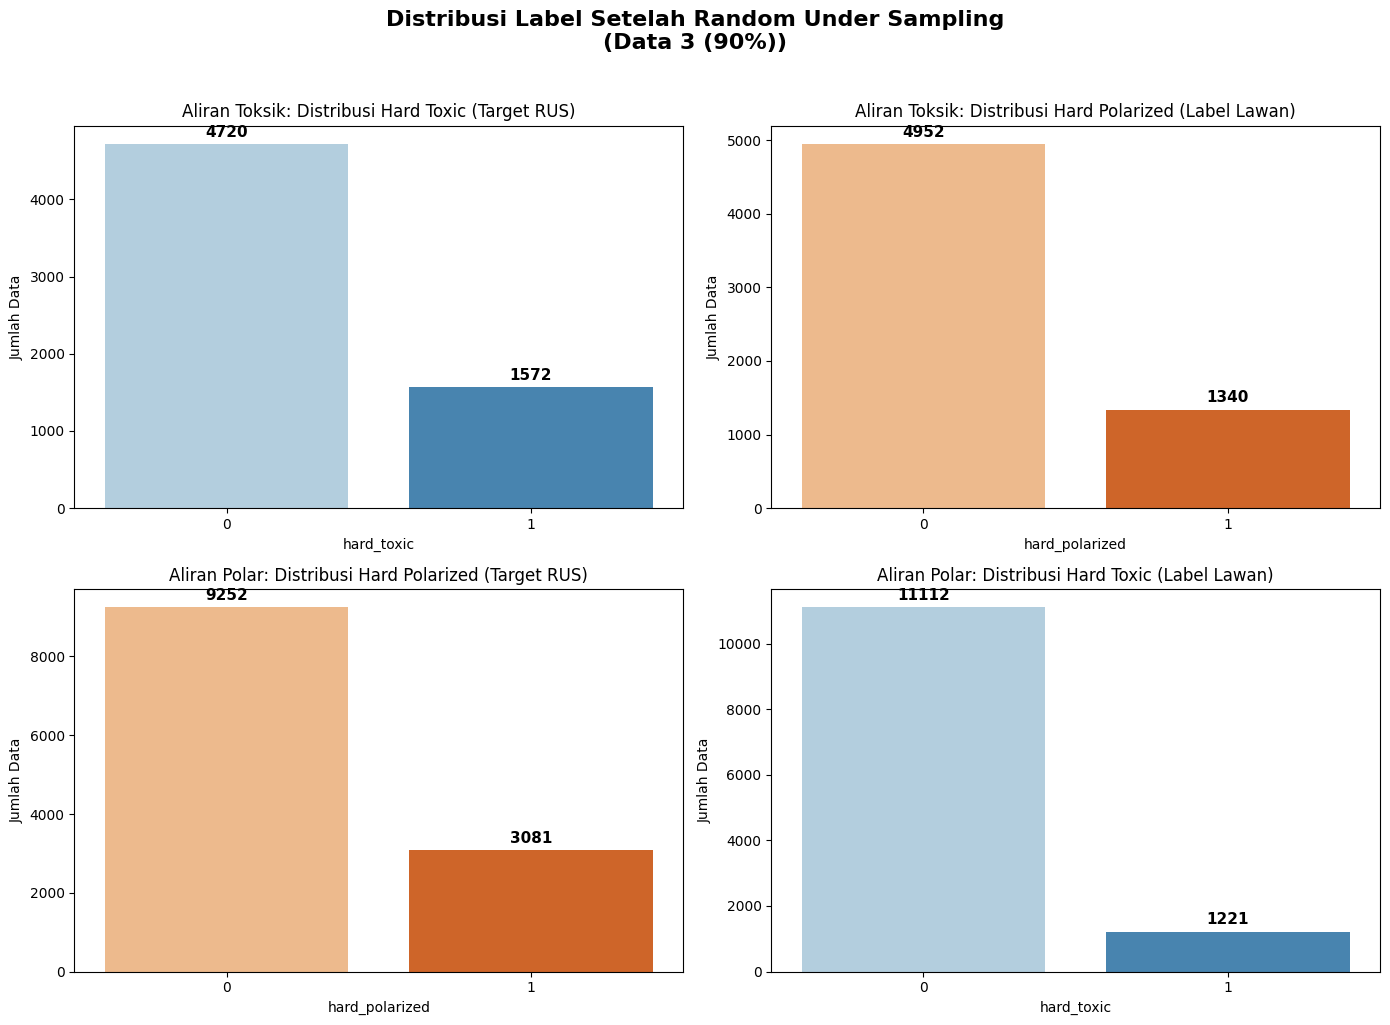

In [26]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Buat fungsi agar kode tidak perlu ditulis berulang kali daris ganteng muaghhhhh
def proses_rus_multitask(df, nama_data):
    # Strategi 0.333 untuk rasio 1:3
    rus = RandomUnderSampler(sampling_strategy=0.333, random_state=42)

    print(f"\n" + "="*45)
    print(f"       PROSES RUS: {nama_data}")
    print("="*45 + "\n")

    # ==========================================
    # ALIRAN 1: Pemangkasan berdasarkan TOKSIK
    # ==========================================
    X_toxic_input = df.drop(columns=['hard_toxic'])
    y_toxic_target = df['hard_toxic']

    X_res_toxic, y_res_toxic = rus.fit_resample(X_toxic_input, y_toxic_target)

    # Gabungkan kembali utuh 5 kolom
    df_rus_toxic = X_res_toxic.copy()
    df_rus_toxic['hard_toxic'] = y_res_toxic

    # ==========================================
    # ALIRAN 2: Pemangkasan berdasarkan POLARIZED
    # ==========================================
    X_polar_input = df.drop(columns=['hard_polarized'])
    y_polar_target = df['hard_polarized']

    X_res_polar, y_res_polar = rus.fit_resample(X_polar_input, y_polar_target)

    # Gabungkan kembali utuh 5 kolom
    df_rus_polarized = X_res_polar.copy()
    df_rus_polarized['hard_polarized'] = y_res_polar

    # ==========================================
    # VISUALISASI HASIL DISTRIBUSI (BAR CHART)
    # ==========================================
    # Membuat figure dengan 2 baris dan 2 kolom
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    fig.suptitle(f'Distribusi Label Setelah Random Under Sampling\n({nama_data})', fontsize=16, fontweight='bold', y=1.02)

    # Plot 1: Aliran Toksik (Target RUS: hard_toxic)
    sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
    axes[0, 0].set_title('Aliran Toksik: Distribusi Hard Toxic (Target RUS)')

    # Plot 2: Aliran Toksik (Label Lawan: hard_polarized)
    sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
    axes[0, 1].set_title('Aliran Toksik: Distribusi Hard Polarized (Label Lawan)')

    # Plot 3: Aliran Polar (Target RUS: hard_polarized)
    sns.countplot(data=df_rus_polarized, x='hard_polarized', ax=axes[1, 0], palette='Oranges')
    axes[1, 0].set_title('Aliran Polar: Distribusi Hard Polarized (Target RUS)')

    # Plot 4: Aliran Polar (Label Lawan: hard_toxic)
    sns.countplot(data=df_rus_polarized, x='hard_toxic', ax=axes[1, 1], palette='Blues')
    axes[1, 1].set_title('Aliran Polar: Distribusi Hard Toxic (Label Lawan)')

    # Menambahkan angka di atas masing-masing bar (batang)
    for ax in axes.flat:
        for p in ax.patches:
            height = p.get_height()
            # Hanya tulis angka jika tinggi bar > 0 (mengatasi error NaN/None)
            if height > 0:
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 3), textcoords='offset points',
                            fontsize=11, fontweight='bold')

        # Rapikan label sumbu y
        ax.set_ylabel('Jumlah Data')

    # Merapikan jarak antar grafik dan menampilkannya
    plt.tight_layout()
    plt.show()

    return df_rus_toxic, df_rus_polarized

# ==========================================
# EKSEKUSI UNTUK SEMUA DATA TRAIN
# ==========================================

# 1. Proses train_data1 (70%)
df_train1_rus_toxic, df_train1_rus_polarized = proses_rus_multitask(train_data1, "Data 1 (70%)")

# 2. Proses train_data2 (80%)
df_train2_rus_toxic, df_train2_rus_polarized = proses_rus_multitask(train_data2, "Data 2 (80%)")

# 3. Proses train_data3 (90%)
df_train3_rus_toxic, df_train3_rus_polarized = proses_rus_multitask(train_data3, "Data 3 (90%)")

In [27]:

print("\n---OVERVIEW DATA PENELITIAN ---")
print("data non rus 1 :",train_data1.shape)
print("data non rus 2 :",train_data2.shape)
print("data non rus 3 :",train_data3.shape)

print("data rus 1 (toxic) :",df_train1_rus_toxic.shape)
print("data rus 2 (toxic) :",df_train2_rus_toxic.shape)
print("data rus 3 (toxic) :",df_train3_rus_toxic.shape)

print("data rus 1 (polarized) :",df_train1_rus_polarized.shape)
print("data rus 2 (polarized) :",df_train2_rus_polarized.shape)
print("data rus 3 (polarized) :",df_train3_rus_polarized.shape)

# perkecil train data 1 untuk testing phase evaluasi dan implementasi jadi 5%


---OVERVIEW DATA PENELITIAN ---
data non rus 1 : (15594, 9)
data non rus 2 : (17822, 9)
data non rus 3 : (20050, 9)
data rus 1 (toxic) : (4975, 9)
data rus 2 (toxic) : (5640, 9)
data rus 3 (toxic) : (6292, 9)
data rus 1 (polarized) : (9651, 9)
data rus 2 (polarized) : (11044, 9)
data rus 3 (polarized) : (12333, 9)


In [28]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from transformers import AutoModel, BertTokenizer, AutoConfig
from torch.optim import AdamW
import ast

# ==========================================
# 1. SETUP DEVICE
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# ==========================================
# 2. CLASS DATASET (Multi-Task)
# ==========================================
class MTLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, hard_toxic, soft_toxic, hard_polar, soft_polar):
        self.encodings = encodings
        
        self.hard_toxic = [int(label) for label in hard_toxic]
        self.hard_polar = [int(label) for label in hard_polar]

        # Untuk BCE, kita hanya butuh probabilitas kelas positif (index 0 dari feature engineering)
        self.soft_toxic = self._clean_soft_labels(soft_toxic)
        self.soft_polar = self._clean_soft_labels(soft_polar)

    def _clean_soft_labels(self, soft_labels):
        bersih = []
        for s_label in soft_labels:
            if isinstance(s_label, str) and s_label.startswith('['):
                s_label = ast.literal_eval(s_label)
            if isinstance(s_label, (list, tuple, np.ndarray)):
                bersih.append(float(s_label[0])) 
            else:
                bersih.append(float(s_label))
        return bersih

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        
        item['hard_toxic'] = torch.tensor(self.hard_toxic[idx])
        item['soft_toxic'] = torch.tensor(self.soft_toxic[idx])
        item['hard_polar'] = torch.tensor(self.hard_polar[idx])
        item['soft_polar'] = torch.tensor(self.soft_polar[idx])
        
        return item

    def __len__(self):
        return len(self.hard_toxic)

# ==========================================
# 3. MODEL MULTI-TASK LEARNING (BCE)
# ==========================================
class IndoBERTweetMTL_BCE(nn.Module):
    def __init__(self, model_path="indolem/indobertweet-base-uncased"):
        super(IndoBERTweetMTL_BCE, self).__init__()
        self.bert = AutoModel.from_pretrained(model_path)
        self.dropout = nn.Dropout(0.1)
        
        # Kepala klasifikasi diubah menjadi 1 node (karena BCE menghasilkan 1 probabilitas tunggal)
        self.head_toxic = nn.Linear(self.bert.config.hidden_size, 1)
        self.head_polar = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        
        # Squeeze untuk menghilangkan dimensi ekstra agar bentuknya [batch_size]
        logits_toxic = self.head_toxic(pooled_output).squeeze(-1)
        logits_polar = self.head_polar(pooled_output).squeeze(-1)
        
        return logits_toxic, logits_polar

# ==========================================
# 4. FUNGSI TRAINING UTAMA
# ==========================================
def train_mtl_bce(df_train, df_val, df_test, task="toxic", model_path="indolem/indobertweet-base-uncased", output_dir="./hasil_mtl_bce"):
    os.makedirs(output_dir, exist_ok=True)
    
    epochs = 3 
    batch_size = 16

    print(f"{'='*50}")
    print(f"🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: {task.upper()})")
    print(f"Jumlah Data Latih (Train) : {len(df_train)}")
    print(f"Jumlah Data Validasi (Val): {len(df_val)}")
    print(f"Jumlah Data Uji (Test)    : {len(df_test)}")
    print(f"{'='*50}")

    tokenizer = BertTokenizer.from_pretrained(model_path)
    
    def prepare_data(df):
        encodings = tokenizer(df['text'].tolist(), truncation=True, padding=True, max_length=128, return_tensors='pt')
        return MTLDataset(
            encodings=encodings,
            hard_toxic=df['hard_toxic'].tolist(),
            soft_toxic=df['soft_toxic'].tolist(),
            hard_polar=df['hard_polarized'].tolist(),
            soft_polar=df['soft_polarized'].tolist()
        )

    train_dataset = prepare_data(df_train)
    val_dataset   = prepare_data(df_val)
    test_dataset  = prepare_data(df_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

    model = IndoBERTweetMTL_BCE(model_path)
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=1e-5)
    
    # Fungsi Loss BCE (BCEWithLogitsLoss sudah otomatis memasukkan Sigmoid di dalamnya)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch + 1}/{epochs} ---")
        
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Target untuk BCE berupa float [batch_size]
            s_tox = batch['soft_toxic'].to(device).float()
            s_pol = batch['soft_polar'].to(device).float()

            # Maju (Forward)
            log_tox, log_pol = model(input_ids, attention_mask)
            
            # Hitung Loss langsung pakai Logits (Sigmoid terjadi di dalam fungsi loss_fn)
            loss_tox = loss_fn(log_tox, s_tox)
            loss_pol = loss_fn(log_pol, s_pol)
            
            # Model belajar kedua tugas
            total_loss = loss_tox + loss_pol
            total_train_loss += total_loss.item()

            total_loss.backward()
            optimizer.step()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluasi Validasi
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                
                s_tox = batch['soft_toxic'].to(device).float()
                s_pol = batch['soft_polar'].to(device).float()

                log_tox, log_pol = model(input_ids, attention_mask)
                
                loss_tox = loss_fn(log_tox, s_tox)
                loss_pol = loss_fn(log_pol, s_pol)
                
                total_val_loss += (loss_tox + loss_pol).item()

        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Train Loss (MTL BCE): {avg_train_loss:.4f} | Val Loss (MTL BCE): {avg_val_loss:.4f}")

    # ==========================
    # 5. EVALUASI AKHIR (TEST SET)
    # ==========================
    print(f"\n{'-'*50}")
    print(f"Menghitung Metrik Evaluasi Akhir untuk tugas: {task.upper()}...")
    
    model.eval()
    results = {'preds':[], 'labels':[], 'probs':[], 'softs':[]}

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            log_tox, log_pol = model(input_ids, attention_mask)
            
            # Saat pengujian, kita ubah log_tox / log_pol ke probabilitas asli pakai Sigmoid manual
            if task == 'toxic':
                prob_final = torch.sigmoid(log_tox)
                b_labels = batch['hard_toxic']
                b_softs = batch['soft_toxic']
            else: 
                prob_final = torch.sigmoid(log_pol)
                b_labels = batch['hard_polar']
                b_softs = batch['soft_polar']

            # Threshold 0.5 untuk hard prediction
            preds = (prob_final >= 0.5).long()

            results['preds'].extend(preds.cpu().numpy())
            results['labels'].extend(b_labels.cpu().numpy())
            results['probs'].extend(prob_final.cpu().numpy())
            results['softs'].extend(b_softs.cpu().numpy())

    # Hitung Metrik
    y_true = results['labels']
    y_pred = results['preds']
    probs = results['probs']
    softs = results['softs']

    try:
        roc = roc_auc_score(y_true, probs)
    except ValueError:
        roc = 0.5
        
    probs_np, softs_np = np.array(probs), np.array(softs)
    
    # Custom MAE untuk evaluasi probabilitas vs soft label
    mae_pos = np.abs(probs_np - softs_np)
    mae_neg = np.abs((1.0 - probs_np) - (1.0 - softs_np))
    final_mae = np.mean((mae_pos + mae_neg) / 2)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'roc_auc': roc,
        'mae_soft_label': final_mae
    }

    print(f"\n--- Hasil Evaluasi ({task.upper()}) ---")
    for key, value in metrics.items():
        print(f"- {key}: {value:.4f}")
    
    unik, jumlah = np.unique(y_pred, return_counts=True)
    print(f"\nDistribusi tebakan model: {dict(zip(unik, jumlah))}")

    # Simpan
    torch.save(model.state_dict(), os.path.join(output_dir, f"model_mtl_bce_state.pt"))
    tokenizer.save_pretrained(output_dir)
    pd.DataFrame([metrics]).to_csv(os.path.join(output_dir, f"test_performance_{task}_bce.csv"), index=False)
    
    print("\nTraining selesai! Semua hasil tersimpan di:", output_dir)

Menggunakan device: cuda


In [29]:
df_train = df_train1_rus_toxic
df_test = test_data1
df_val = val_data1

# Jalankan fungsinya
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 4975
Jumlah Data Validasi (Val): 3342
Jumlah Data Uji (Test)    : 3342


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27911.53it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.9112 | Val Loss (MTL BCE): 0.6229

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.7284 | Val Loss (MTL BCE): 0.6238

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.6471 | Val Loss (MTL BCE): 0.6545

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.8938
- macro_f1: 0.7004
- precision: 0.6664
- recall: 0.7694
- roc_auc: 0.8897
- mae_soft_label: 0.1485

Distribusi tebakan model: {np.int64(0): np.int64(2927), np.int64(1): np.int64(415)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [30]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = df_train2_rus_toxic
df_test = test_data2
df_val = val_data2

# Jalankan fung(df_train, df_val, df_test)
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 5640
Jumlah Data Validasi (Val): 2228
Jumlah Data Uji (Test)    : 2228


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18979.18it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.8945 | Val Loss (MTL BCE): 0.6470

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.7467 | Val Loss (MTL BCE): 0.6204

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.6583 | Val Loss (MTL BCE): 0.6325

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.9062
- macro_f1: 0.7057
- precision: 0.6815
- recall: 0.7417
- roc_auc: 0.8891
- mae_soft_label: 0.1309

Distribusi tebakan model: {np.int64(0): np.int64(2003), np.int64(1): np.int64(225)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [31]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = df_train3_rus_toxic
df_test = test_data3
df_val = val_data3

# Jalankan fungsinya
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 6292
Jumlah Data Validasi (Val): 1114
Jumlah Data Uji (Test)    : 1114


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16457.33it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.8865 | Val Loss (MTL BCE): 0.6535

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.7411 | Val Loss (MTL BCE): 0.6126

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.6625 | Val Loss (MTL BCE): 0.6641

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.8833
- macro_f1: 0.7243
- precision: 0.6890
- recall: 0.7962
- roc_auc: 0.8821
- mae_soft_label: 0.1590

Distribusi tebakan model: {np.int64(0): np.int64(946), np.int64(1): np.int64(168)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [32]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data1
df_test = test_data1
df_val = val_data1

# Jalankan fungsinya
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 15594
Jumlah Data Validasi (Val): 3342
Jumlah Data Uji (Test)    : 3342


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12825.63it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.6001 | Val Loss (MTL BCE): 0.5687

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.5141 | Val Loss (MTL BCE): 0.5604

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.4614 | Val Loss (MTL BCE): 0.5808

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.9306
- macro_f1: 0.6747
- precision: 0.7420
- recall: 0.6407
- roc_auc: 0.8788
- mae_soft_label: 0.0984

Distribusi tebakan model: {np.int64(0): np.int64(3206), np.int64(1): np.int64(136)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [33]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data2
df_test = test_data2
df_val = val_data2

# Jalankan fungsinya
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 17822
Jumlah Data Validasi (Val): 2228
Jumlah Data Uji (Test)    : 2228


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13495.67it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.5937 | Val Loss (MTL BCE): 0.5647

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.5183 | Val Loss (MTL BCE): 0.5651

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.4746 | Val Loss (MTL BCE): 0.5762

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.9354
- macro_f1: 0.7310
- precision: 0.7689
- recall: 0.7041
- roc_auc: 0.9009
- mae_soft_label: 0.1083

Distribusi tebakan model: {np.int64(0): np.int64(2106), np.int64(1): np.int64(122)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [34]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data3
df_test = test_data3
df_val = val_data3

# Jalankan fungsinya
train_mtl_bce(df_train, df_val, df_test)

🚀 MEMULAI TRAINING MTL BCE (EVALUASI FOKUS PADA: TOXIC)
Jumlah Data Latih (Train) : 20050
Jumlah Data Validasi (Val): 1114
Jumlah Data Uji (Test)    : 1114


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19423.04it/s]
[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Train Loss (MTL BCE): 0.5914 | Val Loss (MTL BCE): 0.5566

--- Epoch 2/3 ---
Train Loss (MTL BCE): 0.5131 | Val Loss (MTL BCE): 0.5610

--- Epoch 3/3 ---
Train Loss (MTL BCE): 0.4660 | Val Loss (MTL BCE): 0.5946

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir untuk tugas: TOXIC...

--- Hasil Evaluasi (TOXIC) ---
- accuracy: 0.9165
- macro_f1: 0.7023
- precision: 0.7457
- recall: 0.6747
- roc_auc: 0.8853
- mae_soft_label: 0.1039

Distribusi tebakan model: {np.int64(0): np.int64(1045), np.int64(1): np.int64(69)}

Training selesai! Semua hasil tersimpan di: ./hasil_mtl_bce


In [3]:
import pandas as pd
import numpy as np

# Membuat tingkat kolom (MultiIndex)
kolom = pd.MultiIndex.from_tuples([
    ('Tanpa Balancing', '70:15:15', 'Toxic'),
    ('Tanpa Balancing', '70:15:15', 'Polar'),
    ('Tanpa Balancing', '80:10:10', 'Toxic'),
    ('Tanpa Balancing', '80:10:10', 'Polar'),
    ('Tanpa Balancing', '90:5:5', 'Toxic'),
    ('Tanpa Balancing', '90:5:5', 'Polar'),
    ('Random Undersampling', '70:15:15', 'Toxic'),
    ('Random Undersampling', '70:15:15', 'Polar'),
    ('Random Undersampling', '80:10:10', 'Toxic'),
    ('Random Undersampling', '80:10:10', 'Polar'),
    ('Random Undersampling', '90:5:5', 'Toxic'),
    ('Random Undersampling', '90:5:5', 'Polar')
])

# Membuat nama baris model
baris = ['STL & LDL', 'STL & MLL', 'MTL & LDL', 'MTL & MLL']

# Membuat DataFrame dengan isi awal '-'
data = np.full((len(baris), len(kolom)), '-')
df = pd.DataFrame(data, index=baris, columns=kolom)
df.index.name = 'Kombinasi Model'

# Menampilkan tabel
display(df)

Tanpa Balancing                                    \
                       70:15:15       80:10:10       90:5:5         
                          Toxic Polar    Toxic Polar  Toxic Polar   
Kombinasi Model                                                     
STL & LDL                     -     -        -     -      -     -   
STL & MLL                     -     -        -     -      -     -   
MTL & LDL                     -     -        -     -      -     -   
MTL & MLL                     -     -        -     -      -     -   

                Random Undersampling                                    
                            70:15:15       80:10:10       90:5:5        
                               Toxic Polar    Toxic Polar  Toxic Polar  
Kombinasi Model                                                         
STL & LDL                          -     -        -     -      -     -  
STL & MLL                          -     -        -     -      -     -  
MTL & LDL                          -     -        -     -      -     -  
MTL & MLL                          -     -        -     -      -     -